# Impor packages

In [10]:
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [36]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

In [12]:
!gdown 1eW2Q28waJqBxeJqf6cwoV3wMWTttlW5b

Downloading...
From: https://drive.google.com/uc?id=1eW2Q28waJqBxeJqf6cwoV3wMWTttlW5b
To: /content/Online Retail Data.csv
100% 34.1M/34.1M [00:00<00:00, 73.7MB/s]


# Impor data dari CSV ke DataFrame

In [13]:
df = pd.read_csv('Online Retail Data.csv', header=0)
df

,order_id,product_code,product_name,quantity,order_date,price,customer_id
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.25,14590.0
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0
3,493413,21724,PANDA AND BUNNIES STICKER SHEET,1,2010-01-04 09:54:00,0.85,NaN
4,493413,84578,ELEPHANT TOY WITH BLUE T-SHIRT,1,2010-01-04 09:54:00,3.75,NaN
...,...,...,...,...,...,...,...
461768,539991,21618,4 WILDFLOWER BOTANICAL CANDLES,1,2010-12-23 16:49:00,1.25,NaN
461769,539991,72741,GRAND CHOCOLATECANDLE,4,2010-12-23 16:49:00,1.45,NaN
461770,539992,21470,FLOWER VINE RAFFIA FOOD COVER,1,2010-12-23 17:41:00,3.75,NaN
461771,539992,22258,FELT FARM ANIMAL RABBIT,1,2010-12-23 17:41:00,1.25,NaN


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461773 entries, 0 to 461772
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      461773 non-null  object 
 1   product_code  461773 non-null  object 
 2   product_name  459055 non-null  object 
 3   quantity      461773 non-null  int64  
 4   order_date    461773 non-null  object 
 5   price         461773 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 24.7+ MB


# Data cleansing

In [15]:
import pandas as pd
import numpy as np
import datetime as dt
from mlxtend.frequent_patterns import apriori, association_rules
from scipy import stats

df_clean = df.copy()

# Membuat kolom date dengan cara yang lebih modern
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'], errors='coerce')
df_clean = df_clean.dropna(subset=['order_date'])
df_clean['date'] = df_clean['order_date'].dt.normalize()

# Pembersihan data yang lebih efisien
df_clean = df_clean[df_clean['customer_id'].notna()].copy()
df_clean['customer_id'] = df_clean['customer_id'].astype(int).astype(str)

df_clean = df_clean[df_clean['product_name'].notna()]
df_clean['product_name'] = df_clean['product_name'].str.lower().str.strip()

# Filter produk 'test' dan order 'cancelled' (C)
df_clean = df_clean[
    (~df_clean['product_code'].str.lower().str.contains('test')) &
    (~df_clean['order_id'].str.startswith('C', na=False)) &
    (df_clean['price'] > 0)
]

# Normalisasi Quantity & Hitung Amount
df_clean['quantity'] = df_clean['quantity'].abs()
df_clean['amount'] = df_clean['quantity'] * df_clean['price']

# Mengganti product_name ke yang paling sering muncul (Modern GroupBy)
most_freq_name = (
    df_clean.groupby('product_code')['product_name']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={'product_name': 'standard_name'})
)
df_clean = df_clean.merge(most_freq_name, on='product_code', how='left')
df_clean['product_name'] = df_clean['standard_name']
df_clean.drop(columns='standard_name', inplace=True)

# Menghapus outlier menggunakan Z-score
z_scores = np.abs(stats.zscore(df_clean[['quantity', 'amount']]))
df_clean = df_clean[(z_scores < 3).all(axis=1)].reset_index(drop=True)

display(df_clean.head())

,order_id,product_code,product_name,quantity,order_date,price,customer_id,date,amount
0,493414,21844,red retrospot mug,36,2010-01-04 10:28:00,2.55,14590,2010-01-04,91.8
1,493414,21533,retro spot large milk jug,12,2010-01-04 10:28:00,4.25,14590,2010-01-04,51.0
2,493414,37508,new england ceramic cake server,2,2010-01-04 10:28:00,2.55,14590,2010-01-04,5.1
3,493414,35001G,hand open shape gold,2,2010-01-04 10:28:00,4.25,14590,2010-01-04,8.5
4,493414,21527,red retrospot traditional teapot,12,2010-01-04 10:28:00,6.95,14590,2010-01-04,83.4


In [16]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350092 entries, 0 to 350091
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      350092 non-null  object        
 1   product_code  350092 non-null  object        
 2   product_name  350092 non-null  object        
 3   quantity      350092 non-null  int64         
 4   order_date    350092 non-null  datetime64[ns]
 5   price         350092 non-null  float64       
 6   customer_id   350092 non-null  object        
 7   date          350092 non-null  datetime64[ns]
 8   amount        350092 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(4)
memory usage: 24.0+ MB


# Menyiapkan data basket

## Buat DataFrame basket

In [17]:
basket = pd.pivot_table(df_clean, index='order_id', columns='product_name', values='product_code', aggfunc='nunique', fill_value=0)
basket

product_name,10 colour spaceboy pen,12 ass zinc christmas decorations,12 coloured party balloons,12 daisy pegs in wood box,12 egg house painted wood,12 ivory rose peg place settings,12 message cards with envelopes,12 mini toadstool pegs,12 pencil small tube woodland,12 pencils small tube posy,...,zinc heart lattice charger large,zinc heart lattice charger small,zinc heart lattice double planter,zinc heart lattice planter bowl,zinc heart lattice t-light holder,zinc heart lattice tray oval,zinc metal heart decoration,zinc police box lantern,zinc top 2 door wooden shelf,zinc willie winkie candle stick
order_id,,,,,,,,,,,,,,,,,,,,,
493414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
493427,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
493428,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
493432,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
493433,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539981,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
539982,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
539985,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
basket.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16272 entries, 493414 to 539988
Columns: 3842 entries, 10 colour spaceboy pen to zinc willie winkie  candle stick
dtypes: int64(3842)
memory usage: 477.1+ MB


## Encode DataFrame basket dengan nilai True untuk semua nilai di atas 0 dan False untuk semua nilai 0

In [19]:
# Menggunakan .map() sebagai pengganti .applymap() yang sudah deprecated
basket_encode = basket.map(lambda x: x > 0)
display(basket_encode.head())

product_name,10 colour spaceboy pen,12 ass zinc christmas decorations,12 coloured party balloons,12 daisy pegs in wood box,12 egg house painted wood,12 ivory rose peg place settings,12 message cards with envelopes,12 mini toadstool pegs,12 pencil small tube woodland,12 pencils small tube posy,...,zinc heart lattice charger large,zinc heart lattice charger small,zinc heart lattice double planter,zinc heart lattice planter bowl,zinc heart lattice t-light holder,zinc heart lattice tray oval,zinc metal heart decoration,zinc police box lantern,zinc top 2 door wooden shelf,zinc willie winkie candle stick
order_id,,,,,,,,,,,,,,,,,,,,,
493414,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493427,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493428,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493432,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493433,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [20]:
basket_encode.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16272 entries, 493414 to 539988
Columns: 3842 entries, 10 colour spaceboy pen to zinc willie winkie  candle stick
dtypes: bool(3842)
memory usage: 59.7+ MB


## Ambil transaksi dengan banyaknya produk unik lebih dari 1 saja

In [21]:
basket_filter = basket_encode[(basket_encode>0).sum(axis=1)>1]
basket_filter

product_name,10 colour spaceboy pen,12 ass zinc christmas decorations,12 coloured party balloons,12 daisy pegs in wood box,12 egg house painted wood,12 ivory rose peg place settings,12 message cards with envelopes,12 mini toadstool pegs,12 pencil small tube woodland,12 pencils small tube posy,...,zinc heart lattice charger large,zinc heart lattice charger small,zinc heart lattice double planter,zinc heart lattice planter bowl,zinc heart lattice t-light holder,zinc heart lattice tray oval,zinc metal heart decoration,zinc police box lantern,zinc top 2 door wooden shelf,zinc willie winkie candle stick
order_id,,,,,,,,,,,,,,,,,,,,,
493414,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493427,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493428,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493432,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493433,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539978,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
539981,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
539982,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [22]:
basket_filter.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15004 entries, 493414 to 539988
Columns: 3842 entries, 10 colour spaceboy pen to zinc willie winkie  candle stick
dtypes: bool(3842)
memory usage: 55.1+ MB


# Mengaplikasikan apriori algorithm

## Buat list frequent itemset (kumpulan produk yang sering dibeli)

In [23]:
# Mengaplikasikan apriori dengan parameter yang lebih eksplisit
frequent_itemset = apriori(
    basket_filter,
    min_support=0.01,
    use_colnames=True
).sort_values('support', ascending=False).reset_index(drop=True)

frequent_itemset['product_cnt'] = frequent_itemset['itemsets'].apply(len)
display(frequent_itemset.head())

,support,itemsets,product_cnt
0,0.177953,(white hanging heart t-light holder),1
1,0.099440,(regency cakestand 3 tier),1
2,0.096841,(jumbo bag red retrospot),1
3,0.079912,(pack of 72 retro spot cake cases),1
4,0.078512,(assorted colour bird ornament),1


In [24]:
frequent_itemset['product_cnt'] = frequent_itemset['itemsets'].apply(lambda x: len(x))
frequent_itemset

,support,itemsets,product_cnt
0,0.177953,(white hanging heart t-light holder),1
1,0.099440,(regency cakestand 3 tier),1
2,0.096841,(jumbo bag red retrospot),1
3,0.079912,(pack of 72 retro spot cake cases),1
4,0.078512,(assorted colour bird ornament),1
...,...,...,...
1189,0.010064,"(jumbo storage bag suki, jumbo bag red retrosp...",3
1190,0.010064,"(key fob , shed, key fob , back door, key fob ...",3
1191,0.010064,"(jumbo storage bag suki, lunch bag red spotty,...",3
1192,0.010064,"(poppy's playhouse kitchen, poppy's playhouse ...",3


## Hitung nilai support, confidence, dan lift dari setiap pasangan produk yang mungkin

In [29]:
from mlxtend.frequent_patterns import association_rules

# Membuat tabel asosiasi dasar (Support & Confidence diutamakan)
product_association = association_rules(frequent_itemset, metric='confidence', min_threshold=.7)
product_association = product_association.sort_values(['support','confidence'], ascending=[False,False]).reset_index(drop=True)

display(product_association.head())

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(red hanging heart t-light holder),(white hanging heart t-light holder),0.058784,0.177953,0.042455,0.722222,4.058510,1.0,0.031995,2.959371,0.800671,0.218525,0.662090,0.480400
1,(sweetheart ceramic trinket box),(strawberry ceramic trinket box),0.049254,0.074980,0.037457,0.760487,10.142533,1.0,0.033764,3.862089,0.948103,0.431644,0.741073,0.630021
2,(toilet metal sign),(bathroom metal sign),0.026993,0.040589,0.021728,0.804938,19.831353,1.0,0.020632,4.918499,0.975918,0.473837,0.796686,0.670121
3,(red retrospot sugar jam bowl),(red retrospot small milk jug),0.023660,0.037123,0.016796,0.709859,19.121592,1.0,0.015917,3.318652,0.970669,0.381818,0.698673,0.581141
4,(painted metal pears assorted),(assorted colour bird ornament),0.021927,0.078512,0.016596,0.756839,9.639738,1.0,0.014874,3.789618,0.916356,0.197933,0.736121,0.484107


In [33]:
# Top 10 untuk Tim Logistik & Gudang (Fokus Volume Jual)
top_support = product_association.sort_values(['support', 'confidence'], ascending=[False, False]).head(10).reset_index(drop=True)

# Top 10 untuk Tim Marketing (Fokus Bundling/Kekuatan Ikatan)
top_lift = product_association.sort_values('lift', ascending=False).head(10).reset_index(drop=True)

In [34]:
top_support

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(red hanging heart t-light holder),(white hanging heart t-light holder),0.058784,0.177953,0.042455,0.722222,4.058510,1.0,0.031995,2.959371,0.800671,0.218525,0.662090,0.480400
1,(sweetheart ceramic trinket box),(strawberry ceramic trinket box),0.049254,0.074980,0.037457,0.760487,10.142533,1.0,0.033764,3.862089,0.948103,0.431644,0.741073,0.630021
2,(toilet metal sign),(bathroom metal sign),0.026993,0.040589,0.021728,0.804938,19.831353,1.0,0.020632,4.918499,0.975918,0.473837,0.796686,0.670121
3,(red retrospot sugar jam bowl),(red retrospot small milk jug),0.023660,0.037123,0.016796,0.709859,19.121592,1.0,0.015917,3.318652,0.970669,0.381818,0.698673,0.581141
4,(painted metal pears assorted),(assorted colour bird ornament),0.021927,0.078512,0.016596,0.756839,9.639738,1.0,0.014874,3.789618,0.916356,0.197933,0.736121,0.484107
5,"(jumbo bag strawberry, jumbo bag pink with whi...",(jumbo bag red retrospot),0.022527,0.096841,0.016462,0.730769,7.546085,1.0,0.014281,3.354591,0.887473,0.159974,0.701901,0.450381
6,(kitchen metal sign),(bathroom metal sign),0.019861,0.040589,0.016396,0.825503,20.338017,1.0,0.015589,5.498162,0.970098,0.372163,0.818121,0.614722
7,"(key fob , back door)","(key fob , shed)",0.021661,0.025060,0.016062,0.741538,29.590540,1.0,0.015520,3.772089,0.987598,0.523913,0.734895,0.691248
8,"(wooden picture frame white finish, white hang...",(wooden frame antique white),0.022594,0.061250,0.015929,0.705015,11.510382,1.0,0.014545,3.182361,0.934230,0.234544,0.685768,0.482540
9,"(key fob , garage design)","(key fob , shed)",0.019528,0.025060,0.015796,0.808874,32.277503,1.0,0.015306,5.101025,0.988319,0.548611,0.803961,0.719596


In [35]:
top_lift

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(childs garden trowel blue),(childs garden fork blue),0.013530,0.011664,0.010864,0.802956,68.843125,1.0,0.010706,5.015807,0.998990,0.758140,0.800630,0.867192
1,(childs garden fork blue),(childs garden trowel blue),0.011664,0.013530,0.010864,0.931429,68.843125,1.0,0.010706,14.386025,0.997104,0.758140,0.930488,0.867192
2,(poppy's playhouse bathroom),"(poppy's playhouse kitchen, poppy's playhouse ...",0.010997,0.013730,0.010064,0.915152,66.655016,1.0,0.009913,11.623900,0.995950,0.686364,0.913970,0.824081
3,"(poppy's playhouse kitchen, poppy's playhouse ...",(poppy's playhouse bathroom),0.013730,0.010997,0.010064,0.733010,66.655016,1.0,0.009913,3.704266,0.998709,0.686364,0.730041,0.824081
4,(childs garden fork pink),(childs garden trowel pink),0.012330,0.013996,0.011464,0.929730,66.426976,1.0,0.011291,14.031592,0.997242,0.771300,0.928732,0.874389
5,(childs garden trowel pink),(childs garden fork pink),0.013996,0.012330,0.011464,0.819048,66.426976,1.0,0.011291,5.458176,0.998927,0.771300,0.816789,0.874389
6,"(poppy's playhouse bathroom, poppy's playhouse...",(poppy's playhouse livingroom),0.010464,0.014996,0.010064,0.961783,64.135994,1.0,0.009907,25.774271,0.994818,0.653680,0.961202,0.816447
7,(poppy's playhouse bathroom),(poppy's playhouse livingroom),0.010997,0.014996,0.010331,0.939394,62.642963,1.0,0.010166,16.252566,0.994978,0.659574,0.938471,0.814141
8,(childs garden trowel pink),(childs garden trowel blue),0.013996,0.013530,0.011730,0.838095,61.944734,1.0,0.011541,6.092905,0.997822,0.742616,0.835875,0.852545
9,(childs garden trowel blue),(childs garden trowel pink),0.013530,0.013996,0.011730,0.866995,61.944734,1.0,0.011541,7.413287,0.997350,0.742616,0.865107,0.852545


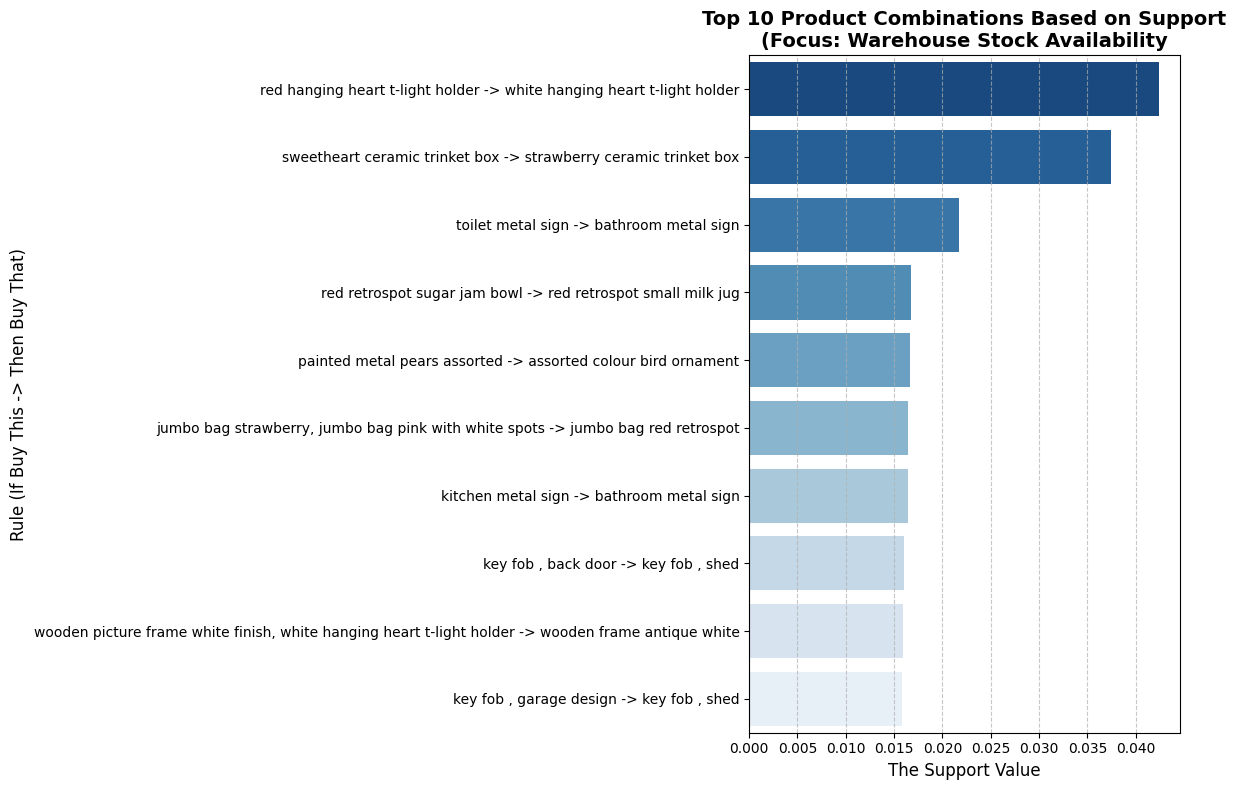

In [47]:
if 'rule' not in product_association.columns:
    product_association['rule'] = (
        product_association['antecedents'].apply(lambda x: ', '.join(list(x))) + ' -> ' +
        product_association['consequents'].apply(lambda x: ', '.join(list(x)))
    )

# Grafik 1: Fokus pada Volume/Ketersediaan Stok (Berdasarkan Support)
top_support = product_association.sort_values(['support', 'confidence'], ascending=[False, False]).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='support',
    y='rule',
    data=top_support,
    palette='Blues_r',
    hue='rule',
    legend=False
)
plt.title('Top 10 Product Combinations Based on Support\n(Focus: Warehouse Stock Availability', fontsize=14, fontweight='bold')
plt.xlabel('The Support Value', fontsize=12)
plt.ylabel('Rule (If Buy This -> Then Buy That)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



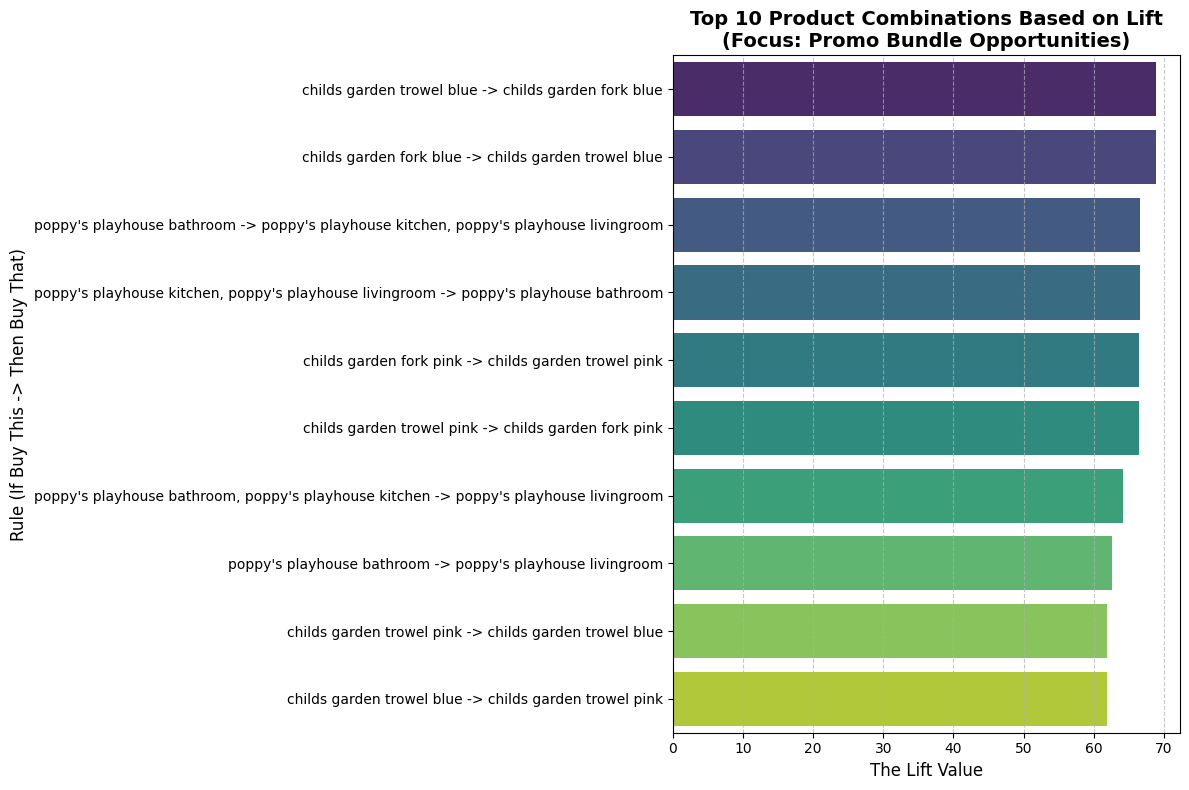

In [48]:
# --- Grafik 2: Fokus pada Peluang Promo/Bundling (Berdasarkan Lift) ---
top_lift = product_association.sort_values('lift', ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='lift',
    y='rule',
    data=top_lift,
    palette='viridis',
    hue='rule',
    legend=False
)
plt.title('Top 10 Product Combinations Based on Lift\n(Focus: Promo Bundle Opportunities)', fontsize=14, fontweight='bold')
plt.xlabel('The Lift Value', fontsize=12)
plt.ylabel('Rule (If Buy This -> Then Buy That)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
